In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datetime import datetime

In [3]:
file_path = 'NEW__ RFQ US Rates - Bonds Only (July - Sept 24) - Blockhouse.xlsx'
df = pd.read_excel(file_path)
df

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40825,2024-07-01,E682EBF3454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 13:48:00,2024-07-01 13:50:00,1,0.03,10-25M,5-7 YR,3y-5y
40826,2024-07-01,E682D1C745CC000A0001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:56:00,2024-07-01 11:58:00,1,0.06,25-50M,5-7 YR,3y-5y
40827,2024-07-01,E682C785454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:13:00,2024-07-01 11:14:00,1,0.03,25-50M,5-7 YR,3y-5y
40828,2024-07-01,E682AFF2454C000C0001,Client736,CustomerTimeOut,"OFFTHERUN,DOUBLEOLDS",0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 09:32:00,2024-07-01 09:34:00,1,0.04,10-25M,5-7 YR,3y-5y


In [4]:
df = df[::-1]
df = df.reset_index(drop=True)

In [5]:
missing_values = df.isnull().sum()
missing_values[:20]

EventDate                  0
Id                         0
Client                     0
RFQStatus                  0
InstrumentSubGroup         0
Mkt Traded Vol             0
Market Traded Vol (USD)    0
Our Traded Vol             0
Our Traded Vol (USD)       0
TiedWonVol                 0
Num of Dealers             0
Trader                     0
Sales                      0
Covered Vol                0
ActionStr                  0
Tier                       0
InstrumentCode             0
InstrumentDescription      0
AssetClass                 0
Market                     0
dtype: int64

In [6]:
missing_values[20:]

LegNo                          0
Maturity Date                  0
RFQNumberOfQuotes              0
Buy/Sell                       0
Best Bid Price                 0
Mid Price                      0
Best Ask Price                 0
Deal Value                     0
AwayFromMid                    0
TickIdentifier               198
Deal Spread                    0
Cover                          0
CoverPnL                       0
SettlementDays                 0
SettlementDate                 0
SettlementStops                0
RFQ CreateTime                 0
RFQ ClosedTime                 0
AnAutoReplyRFQs                0
First Response Time (Sec)      0
TradeSizeBucket                0
Sector                         0
MaturityBucket                 0
dtype: int64

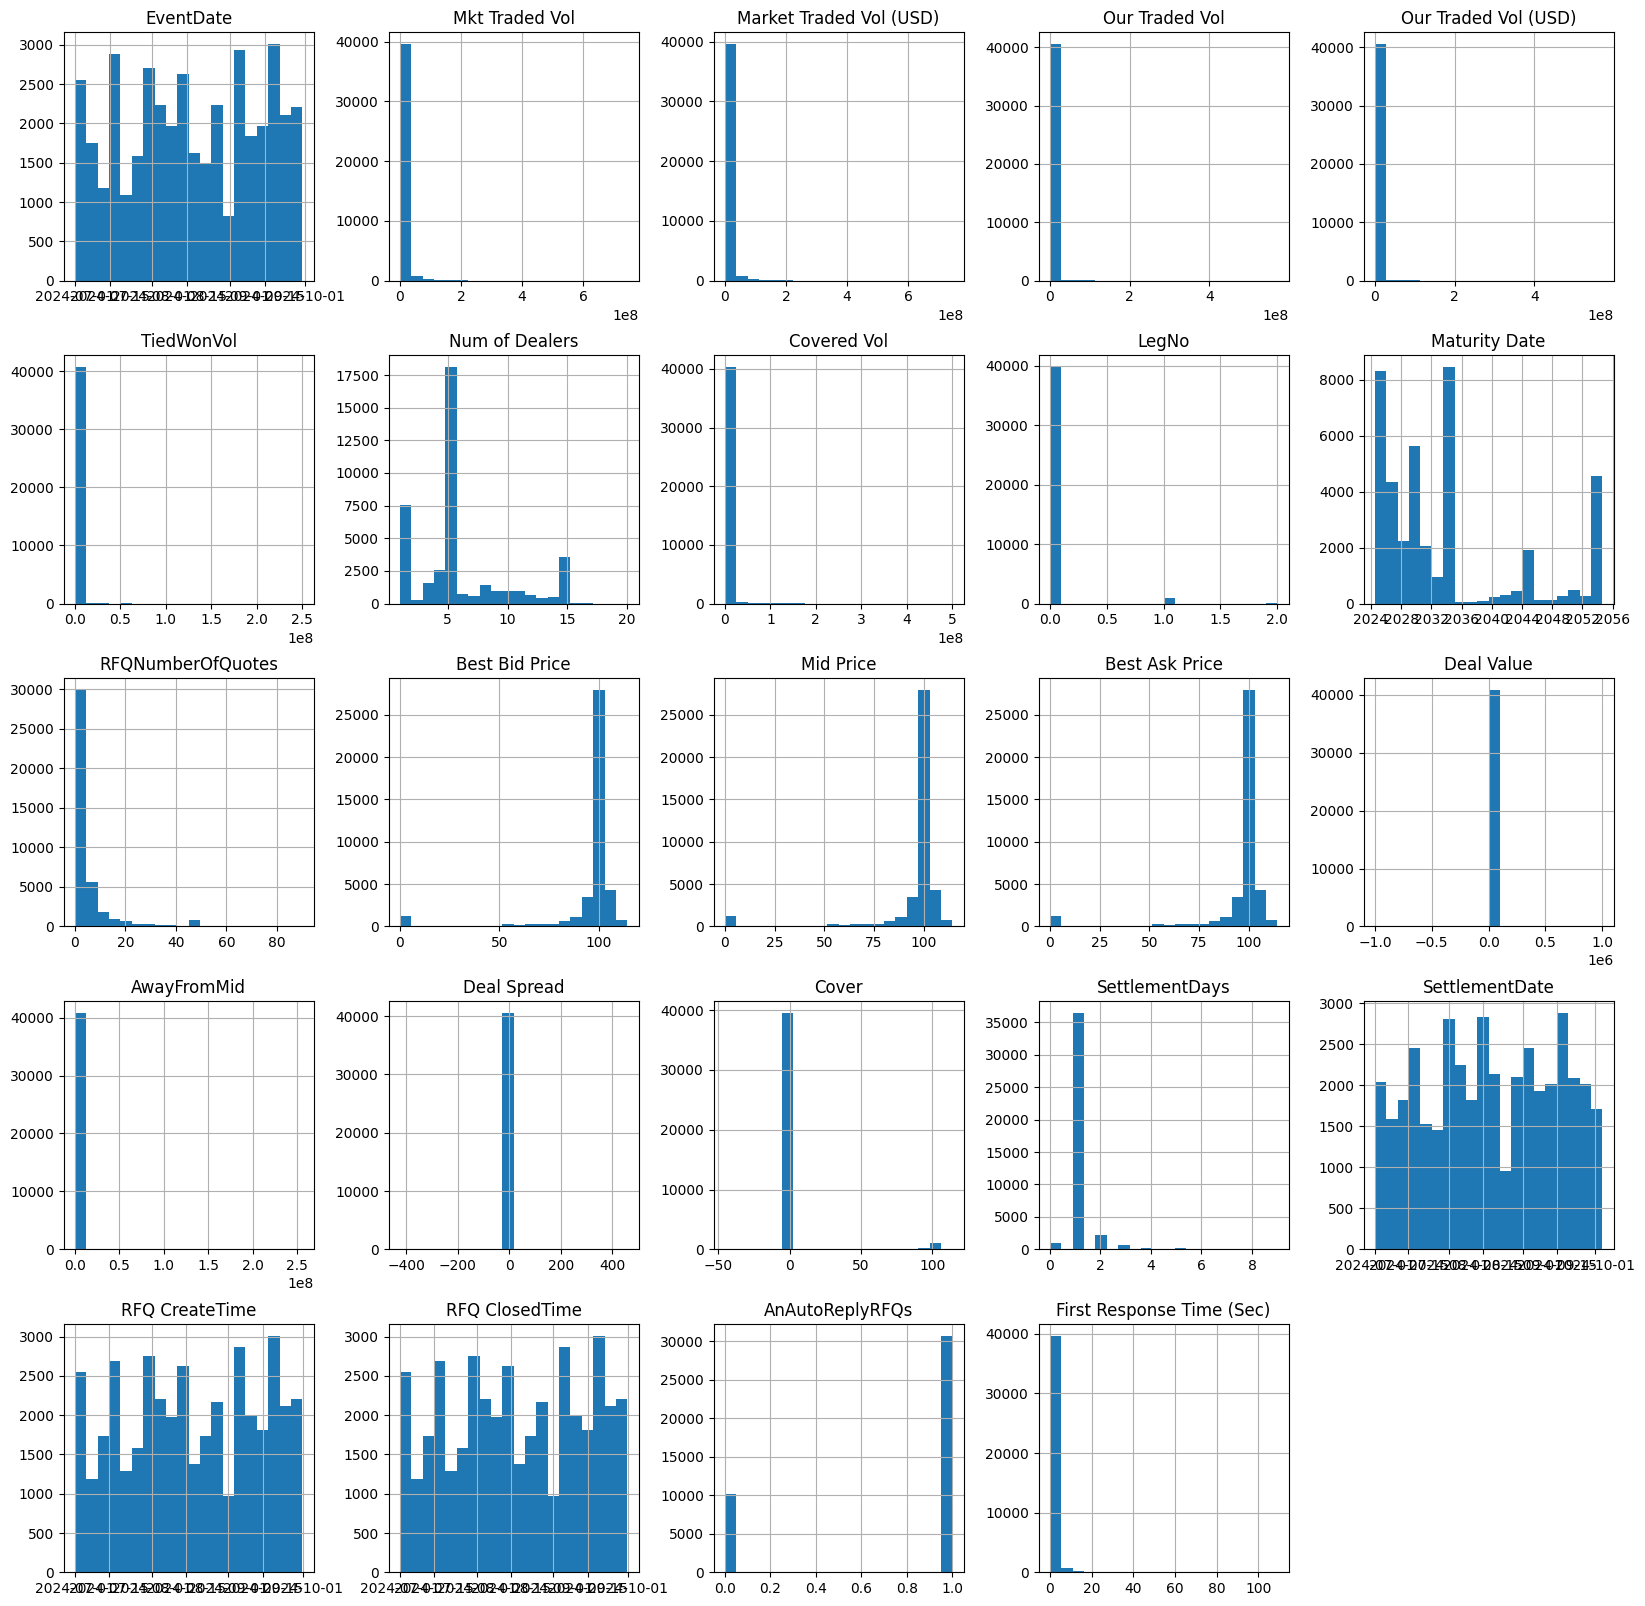

In [7]:
df.hist(bins=20, figsize=(20,20))
plt.show()

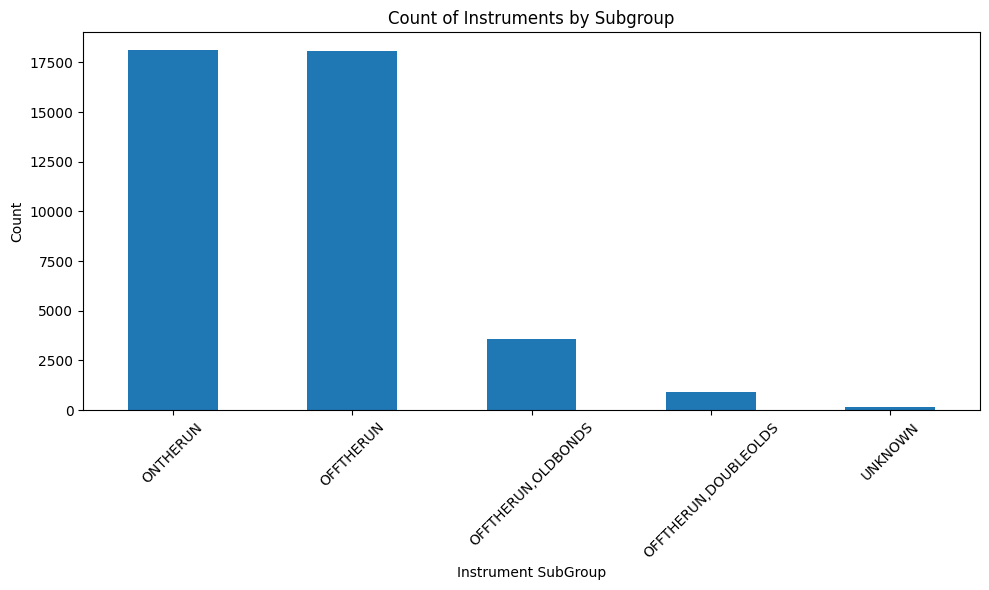

In [8]:
subgroup_counts = df['InstrumentSubGroup'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
subgroup_counts.plot(kind='bar')
plt.title('Count of Instruments by Subgroup')
plt.xlabel('Instrument SubGroup')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
subgroup_counts = df['Maturity Date'].value_counts()
subgroup_counts

Maturity Date
2034-08-15    4159
2034-05-15    3398
2054-05-15    2143
2029-07-31    1591
2029-08-31    1468
              ... 
2038-02-15      13
2046-11-15      13
2024-07-15      12
2045-08-15      11
2045-05-15       9
Name: count, Length: 222, dtype: int64

In [10]:
subgroup_counts = df['MaturityBucket'].value_counts()
subgroup_counts

MaturityBucket
10-30y    10499
<18mos     8457
7y-10y     8065
3y-5y      6827
5y-7y      2747
18m-2y     2218
2y-3y      2017
Name: count, dtype: int64

In [11]:
subgroup_counts = df['Sector'].value_counts()
subgroup_counts

Sector
7-10 YR     11025
15-30 YR     8678
0-1 YR       7508
5-7 YR       7081
2-3 YR       3700
3-5 YR       2587
10-15 YR      202
HCPN           26
TIPS           23
Name: count, dtype: int64

In [12]:
subgroup_counts = df['SettlementDate'].value_counts()
subgroup_counts

SettlementDate
2024-08-15    1214
2024-09-03     957
2024-10-01     896
2024-08-01     884
2024-08-06     876
              ... 
2024-08-12     390
2024-10-02      83
2024-07-01      21
2024-10-03       5
2024-10-04       1
Name: count, Length: 68, dtype: int64

In [13]:
group_30 = df[df['MaturityBucket'] == "10-30y"]
group_30

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
6,2024-07-01,66828A5945CC00110006,Client282,CustomerTimeOut,ONTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 06:52:00,2024-07-01 06:53:00,1,0.06,500K-1M,15-30 YR,10-30y
7,2024-07-01,66829B2857D000050001,Client235,CustomerTimeOut,ONTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 08:04:00,2024-07-01 08:05:00,0,9.20,50+M,15-30 YR,10-30y
10,2024-07-01,66828996E62000090002,Client173,CustomerTimeOut,ONTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 06:49:00,2024-07-01 06:50:00,1,0.04,5-10M,15-30 YR,10-30y
11,2024-07-01,6682AA26E05000280004,Client100,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 09:07:00,2024-07-01 09:09:00,1,0.06,500K-1M,15-30 YR,10-30y
13,2024-07-01,6682B47A57D000780004,Client84,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 09:52:00,2024-07-01 09:54:00,1,0.03,5-10M,15-30 YR,10-30y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40775,2024-09-30,E6FAA99157F000340001,Client736,Done,"OFFTHERUN,OLDBONDS",2000000,2000000,2000000,2000000,0,...,1,2024-10-01,T+1,2024-09-30 09:37:00,2024-09-30 09:37:00,1,0.05,1-5M,15-30 YR,10-30y
40778,2024-09-30,66FB0911432800250001,Client725,Done,ONTHERUN,1300000,1300000,1300000,1300000,0,...,1,2024-10-01,T+1,2024-09-30 16:25:00,2024-09-30 16:25:00,1,0.03,1-5M,15-30 YR,10-30y
40781,2024-09-30,66FACEF3432800120001,Client652,Done,ONTHERUN,1902000,1902000,1902000,1902000,0,...,1,2024-10-01,T+1,2024-09-30 12:16:00,2024-09-30 12:16:00,0,0.21,1-5M,15-30 YR,10-30y
40817,2024-09-30,TRSY_20240930_2189,Client184,Done,ONTHERUN,19200000,19200000,19200000,19200000,0,...,1,2024-10-01,T+1,2024-09-30 16:07:00,2024-09-30 16:07:00,0,0.00,10-25M,15-30 YR,10-30y


In [14]:
group_30['SIGN'] = group_30['Buy/Sell'].apply(lambda x: 1 if x == 'BUY' else -1)
group_30['SIGNED_VOLUME'] = group_30['Our Traded Vol (USD)'] * group_30['SIGN']
group_30

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/765209434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['SIGN'] = group_30['Buy/Sell'].apply(lambda x: 1 if x == 'BUY' else -1)
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/765209434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['SIGNED_VOLUME'] = group_30['Our Traded Vol (USD)'] * group_30['SIGN']


,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,SIGN,SIGNED_VOLUME
6,2024-07-01,66828A5945CC00110006,Client282,CustomerTimeOut,ONTHERUN,0,0,0,0,0,...,T+1,2024-07-01 06:52:00,2024-07-01 06:53:00,1,0.06,500K-1M,15-30 YR,10-30y,-1,0
7,2024-07-01,66829B2857D000050001,Client235,CustomerTimeOut,ONTHERUN,0,0,0,0,0,...,T+1,2024-07-01 08:04:00,2024-07-01 08:05:00,0,9.20,50+M,15-30 YR,10-30y,-1,0
10,2024-07-01,66828996E62000090002,Client173,CustomerTimeOut,ONTHERUN,0,0,0,0,0,...,T+1,2024-07-01 06:49:00,2024-07-01 06:50:00,1,0.04,5-10M,15-30 YR,10-30y,-1,0
11,2024-07-01,6682AA26E05000280004,Client100,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 09:07:00,2024-07-01 09:09:00,1,0.06,500K-1M,15-30 YR,10-30y,-1,0
13,2024-07-01,6682B47A57D000780004,Client84,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 09:52:00,2024-07-01 09:54:00,1,0.03,5-10M,15-30 YR,10-30y,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40775,2024-09-30,E6FAA99157F000340001,Client736,Done,"OFFTHERUN,OLDBONDS",2000000,2000000,2000000,2000000,0,...,T+1,2024-09-30 09:37:00,2024-09-30 09:37:00,1,0.05,1-5M,15-30 YR,10-30y,-1,-2000000
40778,2024-09-30,66FB0911432800250001,Client725,Done,ONTHERUN,1300000,1300000,1300000,1300000,0,...,T+1,2024-09-30 16:25:00,2024-09-30 16:25:00,1,0.03,1-5M,15-30 YR,10-30y,-1,-1300000
40781,2024-09-30,66FACEF3432800120001,Client652,Done,ONTHERUN,1902000,1902000,1902000,1902000,0,...,T+1,2024-09-30 12:16:00,2024-09-30 12:16:00,0,0.21,1-5M,15-30 YR,10-30y,-1,-1902000
40817,2024-09-30,TRSY_20240930_2189,Client184,Done,ONTHERUN,19200000,19200000,19200000,19200000,0,...,T+1,2024-09-30 16:07:00,2024-09-30 16:07:00,0,0.00,10-25M,15-30 YR,10-30y,-1,-19200000


In [15]:
group_30['EventDate'] = pd.to_datetime(group_30['EventDate'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group_30.groupby('EventDate')['Mid Price'].std()

# Map the daily volatility back to the original DataFrame
group_30['Daily_Volatility'] = group_30['EventDate'].map(daily_volatility)
group_30['Daily_Volatility']

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/585876029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['EventDate'] = pd.to_datetime(group_30['EventDate'])
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/585876029.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['Daily_Volatility'] = group_30['EventDate'].map(daily_volatility)


6        18.396335
7        18.396335
10       18.396335
11       18.396335
13       18.396335
           ...    
40775    22.135545
40778    22.135545
40781    22.135545
40817    22.135545
40819    22.135545
Name: Daily_Volatility, Length: 10499, dtype: float64

In [16]:
adv = group_30['Market Traded Vol (USD)'].cumsum()

group_30['ADV'] = adv.iloc[-1] / len(group_30)

group_30['ADV']

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/523241957.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['ADV'] = adv.iloc[-1] / len(group_30)


6        3.724490e+06
7        3.724490e+06
10       3.724490e+06
11       3.724490e+06
13       3.724490e+06
             ...     
40775    3.724490e+06
40778    3.724490e+06
40781    3.724490e+06
40817    3.724490e+06
40819    3.724490e+06
Name: ADV, Length: 10499, dtype: float64

In [35]:
# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['Mid Price'] == 0: return
    if row['Buy/Sell'] == 'Buy':
        return (row['Best Bid Price'] - row['Mid Price'])/row['Mid Price'] * 10000 # Buy side slippage in bps; if in $: row['PRICE'] - row['MID']
    elif row['Buy/Sell'] == 'Sell':
        return (row['Mid Price'] - row['Best Ask Price'])/row['Mid Price'] * 10000 # Sell side slippage in bps; if in $: row['MID'] - row['PRICE']
    return None

# Find the optimal volume

In [65]:
import numpy as np
import math

def ow_with_optimal_volume(data, h_minutes, delta_t=1/24, target_impact=500):
    """
    Calculate impact state I_t, market activity v_t, and optimal trading volume Q_t.

    h_minutes: Time interval for return horizon (in minutes)
    delta_t: Time step for impact decay (in hours)
    target_impact: Desired target impact level (e.g., 50-60 bps)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t), liquidity (v_t), and optimal volume (Q_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    optimal_Q_values = np.full(len(data), np.nan)  # Placeholder for optimal trading volume

    # Initial values for I_t and v_t
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects

            # Calculate optimal Q_t based on the target impact
            Q_t = (target_impact - I_values[i] * (1 - beta * delta_t)) * np.sqrt(adv * v_values[i]) / sigma
            optimal_Q_values[i] = Q_t
        else:
            I_values[i] = I_values[i-1]  # Carry forward the previous impact state if ADV or v_t is zero

    # Assign calculated arrays back to the DataFrame
    data['I_t'] = I_values/10
    data['v_t'] = v_values
    data['Optimal_Q_t'] = abs(optimal_Q_values)

    return data

# Market session

## Dashboard 1

In [66]:
import pandas as pd

group_30_mkt = ow_with_optimal_volume(group_30[group_30['Our Traded Vol (USD)'] != 0], h_minutes=120, delta_t=1/24)
group_30_mkt = group_30_mkt.dropna()

# Assuming your DataFrame is named `df` and 'RFQ CreateTime' is in datetime format
group_30_mkt['RFQ CreateTime'] = pd.to_datetime(group_30_mkt['RFQ CreateTime'])

# Define a function to categorize into specific market sessions
def get_market_session(time):
    if time.hour == 8 and time.minute < 30 or time.hour < 8:  # Pre-market: 8:00 - 9:30
        return 'Pre-market'
    elif (time.hour == 9 and time.minute >= 30) or (time.hour > 9 and time.hour < 12):  # Morning: 9:30 - 12:00
        return 'Morning'
    elif time.hour == 12 or (time.hour == 13 and time.minute < 60):  # Mid-day: 12:00 - 14:00
        return 'Mid-day'
    elif (time.hour == 14 or time.hour == 15) and (time.hour < 16):  # Afternoon: 14:00 - 16:00
        return 'Afternoon'
    else:  # Post-market: anything after 16:00
        return 'Post-market'

# Apply the function to create a new column for market session
group_30_mkt['Market_Session'] = group_30_mkt['RFQ CreateTime'].apply(get_market_session)
group_30_mkt['Signed_Volume_Weighted_Impact'] = group_30_mkt['I_t']
group_30_mkt['Upper_Limited_Volume'] = group_30_mkt['Optimal_Q_t']
group_30_mkt['Our Traded Vol (USD)'] = group_30_mkt['Our Traded Vol (USD)'] * 100
group_30_mkt['Slippage_bps'] = group_30_mkt.apply(calculate_slippage, axis=1)
group_30_mkt['Weighted_Slippage'] = group_30_mkt['Slippage_bps'] * group_30_mkt['Our Traded Vol (USD)']
volume_weighted_slippage = group_30_mkt.groupby(['Market_Session']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['Our Traded Vol (USD)'].abs().sum())
)

session_order = ['Pre-market', 'Morning', 'Mid-day', 'Afternoon', 'Post-market']
group_30_mkt['Market_Session'] = pd.Categorical(group_30_mkt['Market_Session'], categories=session_order, ordered=True)

# Now group by 'Volatility_Group' and 'Market_Session'
grouped_df = group_30_mkt.groupby(['Market_Session']).agg(
    Notional_Valie=('Our Traded Vol (USD)', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean'),  # Sum of optimal volumes
    Dealer_Count=('Client', 'nunique') ,
).reset_index()

# Reset the index of volume_weighted_slippage to ensure proper alignment
volume_weighted_slippage = volume_weighted_slippage.reset_index()
volume_weighted_slippage.columns = ['Market_Session', 'Volume_weighted_Order_Slippage']

# Now, merge with grouped_df on 'Market_Session'
grouped_df = grouped_df.merge(volume_weighted_slippage, on='Market_Session', how='left')
grouped_df

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/2107858049.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_weighted_slippage = group_30_mkt.groupby(['Market_Session']).apply(
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/2107858049.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = group_30_mkt.groupby(['Market_Session']).agg(


,Market_Session,Notional_Valie,Total_Signed_Volume,Price_Impact,Upper_Limited_Volume,Dealer_Count,Volume_weighted_Order_Slippage
0,Pre-market,66076900000,-660769000,-406.542040,1.101635e+09,44,-1.094156
1,Morning,128923630000,-1289236300,-506.961869,1.254561e+09,45,-1.026247
2,Mid-day,69296400000,-692964000,-422.087487,1.152547e+09,27,-1.028100
3,Afternoon,83709700000,-837097000,-431.597210,1.156276e+09,24,-0.605654
4,Post-market,126567390000,-1265673900,-451.181524,1.210356e+09,44,-0.834597


# Volatility

## Dashboard 2

In [ ]:
group_30_mkt['Volatility_Group'] = pd.qcut(group_30_mkt['Daily_Volatility'], q=3, labels=["Low", "Medium", "High"])

# Group by 'Volatility_Group' and calculate total notional traded
grouped_df = group_30_mkt.groupby('Volatility_Group').agg(
    Notional_Valie=('Our Traded Vol (USD)', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean'),  # Sum of optimal volumes
    Dealer_Count=('Client', 'nunique') ,
).reset_index()

volume_weighted_slippage = group_30_mkt.groupby(['Volatility_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['Our Traded Vol (USD)'].abs().sum())
)

# Reset the index of volume_weighted_slippage to ensure proper alignment
volume_weighted_slippage = volume_weighted_slippage.reset_index()
volume_weighted_slippage.columns = ['Volatility_Group', 'Volume_weighted_Order_Slippage']

# Now, merge with grouped_df on 'Market_Session'
grouped_df = grouped_df.merge(volume_weighted_slippage, on='Volatility_Group', how='left')
grouped_df

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/2550185757.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = group_30_mkt.groupby('Volatility_Group').agg(
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/2550185757.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_weighted_slippage = group_30_mkt.groupby(['Volatility_Group']).apply(
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/2550185757.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas 

,Volatility_Group,Notional_Valie,Total_Signed_Volume,Price_Impact,Upper_Limited_Volume,Dealer_Count,Volume_weighted_Order_Slippage
0,Low,141824520000,-1418245200,-613.116816,1.750045e+09,50,-0.794303
1,Medium,147546550000,-1475465500,-361.107121,9.988072e+08,57,-1.226072
2,High,185202950000,-1852029500,-382.239490,8.111731e+08,60,-0.748515


# Size

## Dashboard 3

In [71]:
group_30_mkt['Size_Group'] = pd.qcut(group_30_mkt['Our Traded Vol (USD)'], q=3, labels=["Small", "Medium", "Large"])

# Group by 'Volatility_Group' and calculate total notional traded
grouped_df = group_30_mkt.groupby('Size_Group').agg(
    Notional_Valie=('Our Traded Vol (USD)', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean'),  # Sum of optimal volumes
    Dealer_Count=('Client', 'nunique') ,
).reset_index()

volume_weighted_slippage = group_30_mkt.groupby(['Size_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['Our Traded Vol (USD)'].abs().sum())
)

# Reset the index of volume_weighted_slippage to ensure proper alignment
volume_weighted_slippage = volume_weighted_slippage.reset_index()
volume_weighted_slippage.columns = ['Size_Group', 'Volume_weighted_Order_Slippage']

# Now, merge with grouped_df on 'Market_Session'
grouped_df = grouped_df.merge(volume_weighted_slippage, on='Size_Group', how='left')
grouped_df

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/4168144739.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = group_30_mkt.groupby('Size_Group').agg(
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/4168144739.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_weighted_slippage = group_30_mkt.groupby(['Size_Group']).apply(
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_64374/4168144739.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

,Size_Group,Notional_Valie,Total_Signed_Volume,Price_Impact,Upper_Limited_Volume,Dealer_Count,Volume_weighted_Order_Slippage
0,Small,17050300000,-170503000,-485.612091,1.247903e+09,39,-0.918564
1,Medium,48829000000,-488290000,-411.918565,1.105785e+09,39,-0.970293
2,Large,408694720000,-4086947200,-458.153347,1.209335e+09,60,-0.903220
